# Exemplar: Build a decision tree

## Introduction

In this activity, you’ll build a decision tree model that makes predictions for a target based on multiple features. Because decision trees are used across a wide array of industries, becoming proficient in the process of building one will help you expand your skill set in a widely-applicable way.   

For this activity, you work as a consultant for an airline. The airline is interested in predicting whether a future customer would be satisfied with their services given previous customer feedback about their flight experience. The airline would like you to construct and evaluate a model that can accomplish this goal. Specifically, they are interested in knowing which features are most important to customer satisfaction.

The data for this activity includes survey responses from 129,880 customers. It includes data points such as class, flight distance, and in-flight entertainment, among others. In a previous activity, you utilized a binomial logistic regression model to help the airline better understand this data. In this activity, your goal will be to utilize a decision tree model to predict whether or not a customer will be satisfied with their flight experience. 

Because this activity uses a dataset from the industry, you will need to conduct basic EDA, data cleaning, and other manipulations to prepare the data for modeling.

In this activity, you’ll practice the following skills:

* Importing packages and loading data
* Exploring the data and completing the cleaning process
* Building a decision tree model 
* Tuning hyperparameters using `GridSearchCV`
* Evaluating a decision tree model using a confusion matrix and various other plots

## Step 1: Imports

Import relevant Python packages. Use `DecisionTreeClassifier`,` plot_tree`, and various imports from `sklearn.metrics` to build, visualize, and evaluate the model.

### Import packages

In [2]:
### YOUR CODE HERE ###

# Standard operational package imports
import numpy as np
import pandas as pd

# Important imports for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import sklearn.metrics as metrics

# Visualization package imports
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Surpress warnings:
def warn(*args, **kwargs):
    
    pass
import warnings
warnings.warn = warn

### Load the dataset

`Pandas` is used to load the **Invistico_Airline.csv** dataset. The resulting pandas DataFrame is saved in a variable named `df_original`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.
**Use a function (read_csv) from the pandas library to read in the csv file.**

In [4]:
# RUN THIS CELL TO IMPORT YOUR DATA.

### YOUR CODE HERE ###

df_original = pd.read_csv("Invistico_Airline.csv") ###

### Output the first 10 rows of data
**if only five rows are output, it is because the head function by default returns five rows. To change this, specify how many rows (n = ) you want to output.**

In [5]:
### YOUR CODE HERE ###

df.head(10)

NameError: name 'df' is not defined

## Step 2: Data exploration, data cleaning, and model preparation

### Prepare the data

After loading the dataset, prepare the data to be suitable for decision tree classifiers. This includes: 

*   Exploring the data
*   Checking for missing values
*   Encoding the data
*   Renaming a column
*   Creating the training and testing data

### Explore the data

Check the data type of each column. Note that decision trees expect numeric data. 

In [6]:
### YOUR CODE HERE ###

df_original.dtypes



satisfaction                          object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
dtype: obj

### Output unique values 

The `Class` column is ordinal (meaning there is an inherent order that is significant). For example, airlines typically charge more for 'Business' than 'Eco Plus' and 'Eco'. Output the unique values in the `Class` column. 

In [7]:
### YOUR CODE HERE ###

df_original["Class"].unique()

array(['Eco', 'Business', 'Eco Plus'], dtype=object)

### Check the counts of the predicted labels

In order to predict customer satisfaction, verify if the dataset is imbalanced. To do this, check the counts of each of the predicted labels. 

In [8]:
### YOUR CODE HERE ###

df_original['satisfaction'].value_counts(dropna = False)

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

**Question:** What percentage of customers were satisfied? 

54.7 percent (71087/129880) of customers were satisfied. This value can be compared to a decision tree's model accuracy. 

### Check for missing values

The sklearn decision tree implementation does not support missing values. Check for missing values in the rows of the data. 
**To get the number of rows in the data with missing values, use the isnull function followed by the sum function.**

In [10]:
### YOUR CODE HERE ###

df_original.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

**Question:** Why is it important to check how many rows and columns there are in the dataset? 

This is important to check because if there are only a small number of missing values in the dataset, they can more safely be removed. 

### Check the number of rows and columns in the dataset
**Use the shape attribute on the DataFrame.**

In [11]:
### YOUR CODE HERE ###

df_original.shape

(129880, 22)

In [12]:
rows, cols = df_original.shape

print("Rows:", rows)
print("Columns:", cols)

Rows: 129880
Columns: 22


### Drop the rows with missing values

Drop the rows with missing values and save the resulting pandas DataFrame in a variable named `df_subset`. **Set the axis parameter passed into the dropna function to 0 if you want to drop rows containing missing values, or 1 if you want to drop columns containing missing values. Optionally, use reset_index to avoid a SettingWithCopy warning later in the notebook.**

In [14]:
### YOUR CODE HERE ###

df_subset = df_original.dropna(axis=0).reset_index(drop=True)

### Check for missing values

Check that `df_subset` does not contain any missing values.

In [15]:
### YOUR CODE HERE ###

df_subset.isna().sum()


satisfaction                         0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

### Check the number of rows and columns in the dataset again

Check how many rows and columns are remaining in the dataset. You should now have 393 fewer rows of data.

In [16]:
### YOUR CODE HERE ###

df_subset.shape ####

(129487, 22)

### Encode the data

Four columns (`satisfaction`, `Customer Type`, `Type of Travel`, `Class`) are the pandas dtype object. Decision trees need numeric columns. Start by converting the ordinal `Class` column into numeric. 

In [18]:
### YOUR CODE HERE ###

df_subset['Class'] = df_subset['Class'].map({"Business": 3, "Eco Plus": 2, "Eco": 1}) 

### Represent the data in the target variable numerically

To represent the data in the target variable numerically, assign `"satisfied"` to the label `1` and `"dissatisfied"` to the label `0` in the `satisfaction` column.  **Transform this column into ordinal numerical data using two different methods: manual encoding with .map() and encoding with OrdinalEncoder from sklearn.**

In [19]:
### YOUR CODE HERE ###

df_subset['satisfaction'] = df_subset['satisfaction'].map({
    'satisfied': 1,
    'dissatisfied': 0
})

### Convert categorical columns into numeric

There are other columns in the dataset that are still categorical. Be sure to convert categorical columns in the dataset into numeric. **Use the get_dummies() function.**

In [21]:
### YOUR CODE HERE ###

df_subset = pd.get_dummies(df_subset, drop_first = True)


### Check column data types

Now that you have converted categorical columns into numeric, check your column data types.

In [22]:
### YOUR CODE HERE ###

df_subset.dtypes

satisfaction                           int64
Age                                    int64
Class                                float64
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Customer Type_disloyal Customer         bool
Type of Travel_Personal Travel          bool
dtype: obj

### Create the training and testing data

Put 75% of the data into a training set and the remaining 25% into a testing set. 

In [24]:
### YOUR CODE HERE ###

y = df_subset["satisfaction"]

X = df_subset.copy()
X = X.drop("satisfaction", axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## Step 3: Model building

### Fit a decision tree classifier model to the data

Make a decision tree instance called `decision_tree` and pass in `0` to the `random_state` parameter. This is only so that if other data professionals run this code, they get the same results. Fit the model on the training set, use the `predict()` function on the testing set, and assign those predictions to the variable `dt_pred`. 

In [29]:
### YOUR CODE HERE ###


decision_tree = DecisionTreeClassifier(random_state=0)
decision_tree.fit(X_train, y_train)
dt_pred = decision_tree.predict(X_test)

## Step 4: Results and evaluation

Print out the decision tree model's accuracy, precision, recall, and F1 score.

In [30]:
### YOUR CODE HERE ###

print("Decision Tree")
print("Accuracy:", "%.6f" % metrics.accuracy_score(y_test, dt_pred))
print("Precision:", "%.6f" % metrics.precision_score(y_test, dt_pred))
print("Recall:", "%.6f" % metrics.recall_score(y_test, dt_pred))
print("F1 Score:", "%.6f" % metrics.f1_score(y_test, dt_pred))

Decision Tree
Accuracy: 0.933523
Precision: 0.938916
Recall: 0.939763
F1 Score: 0.939339


### Produce a confusion matrix

Data professionals often like to know the types of errors made by an algorithm. To obtain this information, produce a confusion matrix.

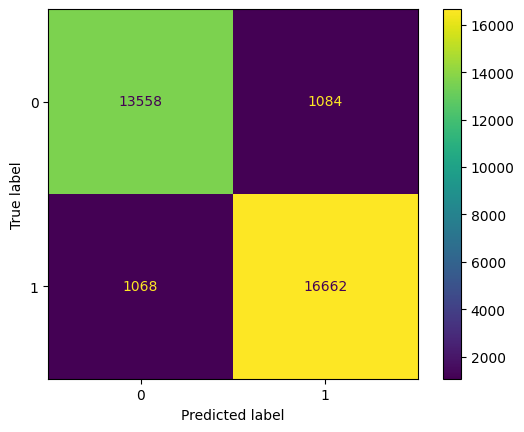

In [31]:
### YOUR CODE HERE ###

cm = metrics.confusion_matrix(y_test, dt_pred, labels = decision_tree.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = decision_tree.classes_)
disp.plot()

**Question:** What patterns can you identify between true positives and true negatives, as well as false positives and false negatives?

In the confusion matrix, there are a high proportion of true positives and true negatives (where the matrix accurately predicted that the customer would be satisfied or dissatified, respectively). 

The matrix also had a relatively low number of false positives and false negatives (where the matrix innacurately predicted that the customer would be satisfied or dissatified, respectively.) 

### Plot the decision tree

Examine the decision tree. Use `plot_tree` function to produce a visual representation of the tree to pinpoint where the splits in the data are occurring.

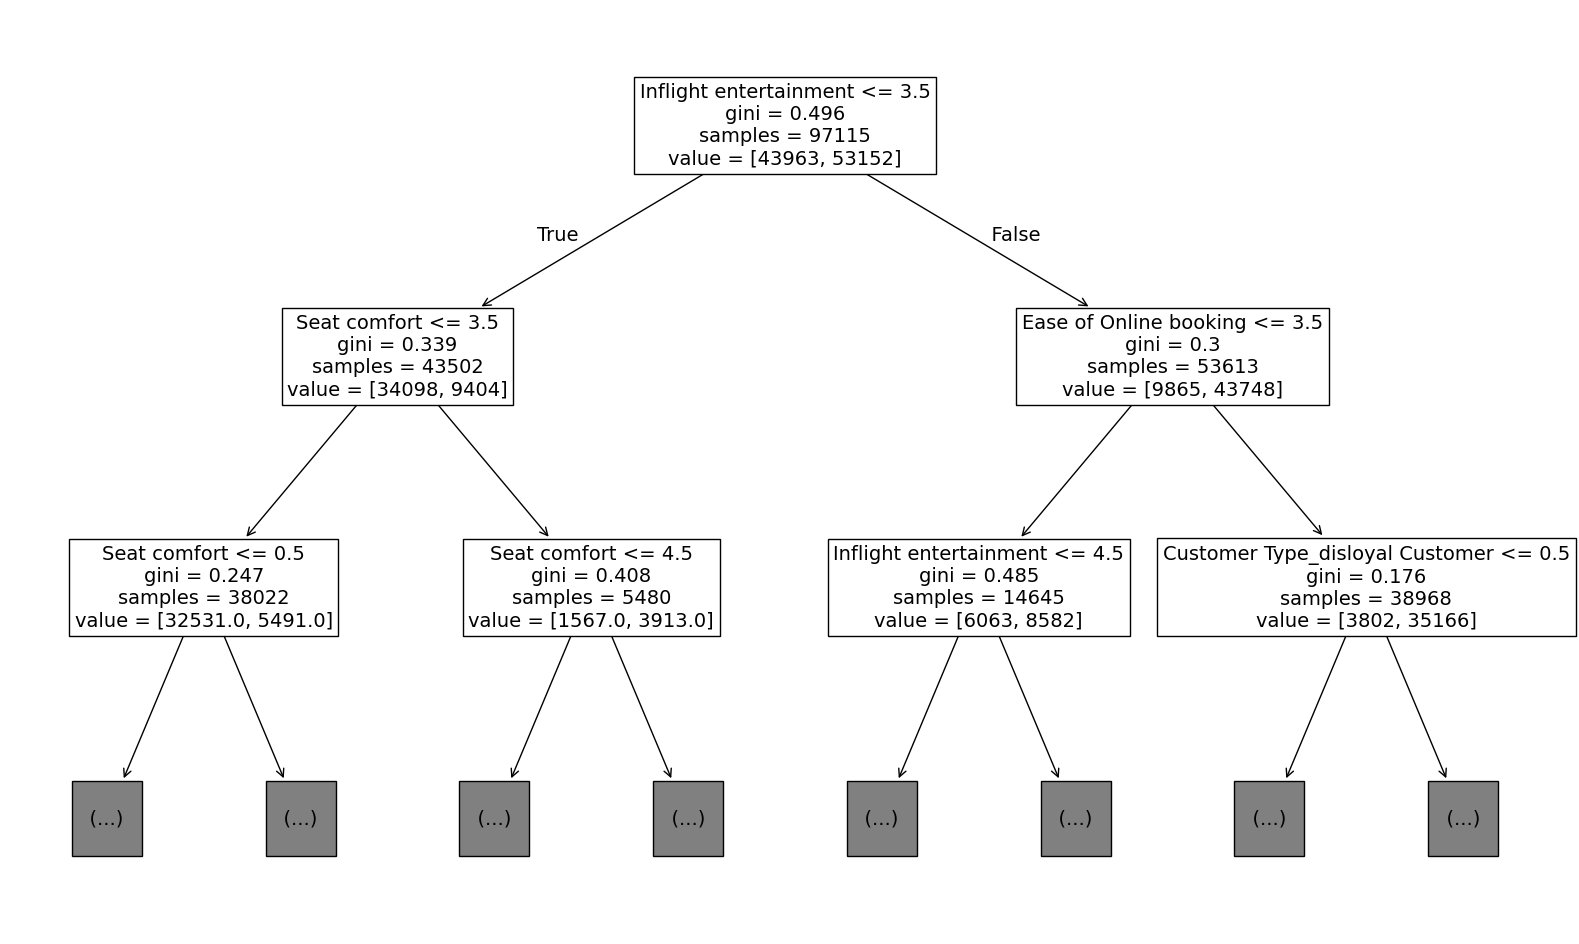

In [32]:
### YOUR CODE HERE ###

plt.figure(figsize=(20,12))
plot_tree(decision_tree, max_depth=2, fontsize=14, feature_names=X.columns);



### Criterion Entropy

In [33]:

decision_tree = ... ####
dt_pred = ...####



# créer le modèle avec entropy
decision_tree = DecisionTreeClassifier(criterion='entropy', random_state=0)

# entraîner le modèle
decision_tree.fit(X_train, y_train)

# faire les prédictions
dt_pred = decision_tree.predict(X_test)

In [34]:
print("Decision Tree")
print("Accuracy:", "%.6f" % metrics.accuracy_score(y_test, dt_pred))
print("Precision:", "%.6f" % metrics.precision_score(y_test, dt_pred))
print("Recall:", "%.6f" % metrics.recall_score(y_test, dt_pred))
print("F1 Score:", "%.6f" % metrics.f1_score(y_test, dt_pred))


Decision Tree
Accuracy: 0.933677
Precision: 0.938785
Recall: 0.940214
F1 Score: 0.939499


### Compare with the results obtained using the Gini index as the splitting criterion.

In [35]:
from sklearn.tree import DecisionTreeClassifier

# modèle avec Gini 
decision_tree_gini = DecisionTreeClassifier(criterion='gini', random_state=0)

decision_tree_gini.fit(X_train, y_train)

gini_pred = decision_tree_gini.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score

# accuracy Entropy
acc_entropy = accuracy_score(y_test, dt_pred)

# accuracy Gini
acc_gini = accuracy_score(y_test, gini_pred)

print("Entropy Accuracy:", acc_entropy)
print("Gini Accuracy:", acc_gini)

Entropy Accuracy: 0.9336772519461263
Gini Accuracy: 0.9335227974793031


### Question: Are there any additional steps you could take to improve the performance or function of your decision tree?



To improve the decision tree, we could tune its hyperparameters, control its depth to reduce overfitting, use cross-validation, and evaluate the model with additional metrics such as precision, recall, F1-score, and a confusion matrix.

## Pre-pruning

In [41]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

clf = DecisionTreeClassifier(random_state=0)

grid_param = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=grid_param,
    scoring='f1',
    n_jobs=-1,
    error_score='raise'
)

grid_search.fit(X_train, y_train)

GridSearchCV(error_score='raise',
             estimator=DecisionTreeClassifier(random_state=0), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [42]:
print(grid_search.best_params_)

{'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}


### Use the best parameters obtained to train the model

In [45]:

                           clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=15,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=0
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=15, min_samples_split=5, random_state=0)

In [47]:
y_pred = clf.predict(X_test)

In [48]:
print("Decision Tree Pre-pruning")
print("Accuracy:", "%.6f" % metrics.accuracy_score(y_test, y_pred))
print("Precision:", "%.6f" % metrics.precision_score(y_test, y_pred))
print("Recall:", "%.6f" % metrics.recall_score(y_test, y_pred))
print("F1 Score:", "%.6f" % metrics.f1_score(y_test, y_pred))

Decision Tree Pre-pruning
Accuracy: 0.938342
Precision: 0.951245
Recall: 0.935364
F1 Score: 0.943237


## Pre-pruning : Second method

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

accuracy = []

for depth in range(1, 21):
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=0)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy.append(accuracy_score(y_test, y_pred))

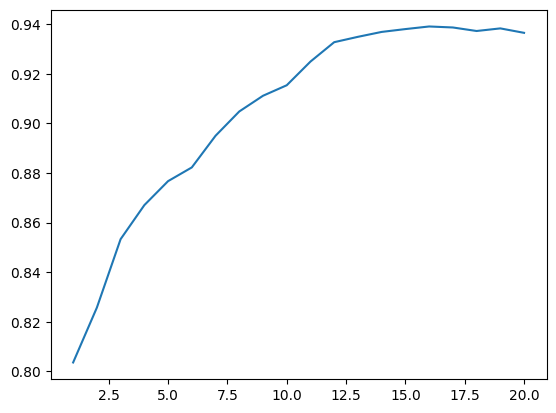

In [51]:
plt.plot(range(1, 21), accuracy)

In [52]:
clf=DecisionTreeClassifier(max_depth= 23,random_state=0)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Decision Tree Pre-pruning")
print("Accuracy:", "%.6f" % metrics.accuracy_score(y_test, y_pred))
print("Precision:", "%.6f" % metrics.precision_score(y_test, y_pred))
print("Recall:", "%.6f" % metrics.recall_score(y_test, y_pred))
print("F1 Score:", "%.6f" % metrics.f1_score(y_test, y_pred))

Decision Tree Pre-pruning
Accuracy: 0.936056
Precision: 0.945139
Recall: 0.937676
F1 Score: 0.941393


## Post-pruning

Use the **cost_complexity_pruning_path** method from scikit-learn to list all the ccp_alpha values obtained during the pruning of a decision tree trained on X_train and y_train.

In [55]:
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=15,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=0
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=15, min_samples_split=5, random_state=0)

After obtaining the list of ccp_alpha values using the cost_complexity_pruning_path method, propose a method to automatically test all these values in order to select the one that maximizes the model's performance.

In [ ]:
 #your code here
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Get ccp_alpha values
clf = DecisionTreeClassifier(random_state=0)

path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# GridSearch on all alpha values
param_grid = {
    "ccp_alpha": ccp_alphas
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)



In [ ]:
print("Best alpha:", grid_search.best_params_['ccp_alpha'])
print("Best score:", grid_search.best_score_)

In [47]:
best=grid_search.best_estimator_
y_pred = best.predict(X_test)
print("Decision Tree Post-pruning")
print("Accuracy:", "%.6f" % metrics.accuracy_score(y_test, y_pred))
print("Precision:", "%.6f" % metrics.precision_score(y_test, y_pred))
print("Recall:", "%.6f" % metrics.recall_score(y_test, y_pred))
print("F1 Score:", "%.6f" % metrics.f1_score(y_test, y_pred))

Decision Tree Post-pruning
Accuracy: 0.944242
Precision: 0.959437
Recall: 0.937845
F1 Score: 0.948518


**Question:** Was the additional performance improvement from hyperparameter tuning worth the computational cost? Why or why not?


### BONUS STEP: Calculate feature importance

The `DecisionTreeClassifier` class comes with a [`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.feature_importances_) attribute that provides access to the features' relative importance in the model. The feature importances are computed when the `fit()` method is called on the `DecisionTreeClassifier` instance. In other words, it's information that is generated during model training. Here's how it works.

For each feature used in the tree, the algorithm finds all of the decision nodes that use that particular feature as the split criterion. Then for each of those decision nodes it computes the decrease in Gini impurity (or entropy) that results from that split (so, the decrease from parent to children). Then the algorithm sums up the decreases across all the decisions made using that feature and expresses it as a percentage of the total decrease that resulted from _all_ features. 

Here is a simple example of how you can calculate feature importance from a tree diagram. This tree splits 10 samples using two features, X<sub>1</sub> and X<sub>2</sub>:

<img src='./SR-003_build_a_decision_tree_graphic.png'/>

Notice that the reduction in Gini impurity is weighted based on how many samples are in each node. Ultimately, the reduction that results from each feature is normalized (i.e., expressed as a percentage), and this percentage represents the importance of a given feature.

This can be interpreted as: X<sub>1</sub> is responsible for 64.3% of the overall reduction of Gini impurity in the model, and X<sub>2</sub> is responsible for 35.7% of the overall reduction of Gini impurity in the model.

Using the `feature_importances_` attribute to fetch the relative importances of each feature, you can then plot the results.

In [ ]:
importances = decision_tree.feature_importances_

forest_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax);

The feature importance graph seems to confirm that `'Inflight entertainment'`, `'Seat comfort'`, and `'Ease of Online booking'` are the most important features for this model. 

## Considerations

**What are some key takeaways that you learned from this lab?**
*   Machine learning workflows may be used to clean and encode data for machine learning.
*   While hyperparameter tuning can lead to an increase in performance, it doesn't always. 
*   The visualization of the decision tree as well as the feature graph can be used to determine which features are most important for a decision tree.

**What would you recommend to stakeholders?**
*  Customer satisfaction is highly tied to `'Inflight entertainment'`, `'Seat comfort'`, and `'Ease of Online booking'`. Improving these experiences should lead to better customer satisfaction. 